# ML Workflow for Flood Mapping — PyCaret Demo

## 1. Import Packages
The most important package that we will use is PyCaret which gives us capability of comparing and evaluating several algorithms at the same time. 

In [1]:
from pycaret.classification import *
import pandas as pd
import numpy as np
import rasterio
from sklearn.metrics import confusion_matrix
from visualization import visulization_plot
import matplotlib.pyplot as plt

## 2. Train and Test On Single Event
Here we will only train and test various algorithms on the dataset of one event. We use 10% of data randomly to train the model and the rest to test the model. 

The dataset represents Hurricane Helene's flood extent. Each row is one pixel. The target column Validation is binary: 1 = flooded, 0 = not flooded. Features include topographic indices (DEM, slope, TWI), soil properties, and land cover variables derived from various sources.

### 2.1. Load the data for Helene event

In [2]:
# Load raw data
df = pd.read_parquet('./results/helene_flood_ml_input_raw.parquet')
print(f"✅ Raw DataFrame shape: {df.shape}")

# Track pixel location and remove no-data values (-9999)
df['pixel_index'] = np.arange(df.shape[0])
df_clean = df[(df != -9999).all(axis=1)].copy()
pixel_indices = df_clean['pixel_index'].values

print(f"✅ Cleaned DataFrame shape: {df_clean.shape}")
df_clean

✅ Raw DataFrame shape: (355425, 10)
✅ Cleaned DataFrame shape: (293050, 11)


,VV,VH,DEM,LandUse,Validation,Wetness Index,Flood,Upstream Area,Water Occurrence,Precipitation,pixel_index
693,-6.730273,-14.181442,293.687256,1,0,414.275635,0.001075,0.007102,0,166.539001,693
694,-5.749596,-14.902246,288.914764,3,0,492.967316,0.002524,0.014204,0,169.759979,694
697,-7.442350,-14.466669,289.340302,1,0,449.071381,0.041750,0.099426,0,169.759979,697
698,-7.930085,-14.081160,293.087952,3,0,420.831543,0.004588,0.071018,0,169.759979,698
699,-7.684586,-12.890235,298.929565,3,0,427.541931,0.003736,0.049713,0,169.759979,699
...,...,...,...,...,...,...,...,...,...,...,...
354072,-8.798215,-15.201440,264.650665,1,0,429.890045,0.004551,0.007138,0,199.487000,354072
354073,-9.648653,-14.822256,262.600708,1,0,419.694275,0.263686,0.028551,0,199.487000,354073
354074,-9.531605,-15.886404,262.479675,1,0,497.669495,0.441594,3.633565,0,199.487000,354074
354075,-9.448602,-16.233620,268.021545,1,0,415.593719,0.244374,0.007138,0,199.487000,354075


### 2.2. Create a setup
Setup is a function that provides information for the next step of the PyCaret workflow about the training and testing data. 

In [3]:
# Setup the experiment
setup(
    data=df_clean.drop(columns=['pixel_index']),
    target='Validation',
    train_size=0.1,  # default
    session_id=42,
    normalize=True,
    # use_gpu = True,
    ignore_features=['x', 'y']
)


,Description,Value
0,Session id,42
1,Target,Validation
2,Target type,Binary
3,Original data shape,"(293050, 10)"
4,Transformed data shape,"(293050, 10)"
5,Transformed train set shape,"(29305, 10)"
6,Transformed test set shape,"(263745, 10)"
7,Ignore features,2
8,Numeric features,9
9,Preprocess,True


### 2.3. Review the models 
Here you can review the models that will be used in the training and testing steps. 

In [4]:
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


### 2.4. Add CSI metric  
PyCaret provides various metrics for classification and regression tasks. But it also provides the capability to add new metrics. Below we will use a function to calculate CSI and add it to the metrics. 

In [5]:
def csi_score(y, y_pred, **kwargs):
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    return tp / (tp + fn + fp + 1e-10)

add_metric(
    id='csi',
    name='CSI',
    score_func=csi_score,
    greater_is_better=True,
    target='pred'
)

Name                                                               CSI
Display Name                                                       CSI
Score Function       <pycaret.internal.metrics.EncodedDecodedLabels...
Scorer               make_scorer(csi_score, response_method='predict')
Target                                                            pred
Args                                                                {}
Greater is Better                                                 True
Multiclass                                                        True
Custom                                                            True
Name: csi, dtype: object

Then with the command below we can see the metrics for the training. 

In [6]:
get_metrics()

,Name,Display Name,Score Function,Scorer,Target,Args,Greater is Better,Multiclass,Custom
ID,,,,,,,,,
acc,Accuracy,Accuracy,<function accuracy_score at 0x14e7e5e10>,accuracy,pred,{},True,True,False
auc,AUC,AUC,<pycaret.internal.metrics.BinaryMulticlassScor...,"make_scorer(roc_auc_score, response_method=('d...",pred_proba,"{'average': 'weighted', 'multi_class': 'ovr'}",True,True,False
recall,Recall,Recall,<pycaret.internal.metrics.BinaryMulticlassScor...,"make_scorer(recall_score, response_method='pre...",pred,{'average': 'weighted'},True,True,False
precision,Precision,Prec.,<pycaret.internal.metrics.BinaryMulticlassScor...,"make_scorer(precision_score, response_method='...",pred,{'average': 'weighted'},True,True,False
f1,F1,F1,<pycaret.internal.metrics.BinaryMulticlassScor...,"make_scorer(f1_score, response_method='predict...",pred,{'average': 'weighted'},True,True,False
kappa,Kappa,Kappa,<function cohen_kappa_score at 0x14e7e6170>,"make_scorer(cohen_kappa_score, response_method...",pred,{},True,True,False
mcc,MCC,MCC,<function matthews_corrcoef at 0x14e7e63b0>,"make_scorer(matthews_corrcoef, response_method...",pred,{},True,True,False
csi,CSI,CSI,<pycaret.internal.metrics.EncodedDecodedLabels...,"make_scorer(csi_score, response_method='predict')",pred,{},True,True,True


### 2.5. Train and Test Algorithms
With the function below we start training and testing the algorithms:

- **`sort`**: sorts the results based on CSI score
- **`n_select`**: returns only the top 3 best performing models
- **`exclude`**: manually excludes specific models (`rbfsvm` and `gpc`) from the comparison
- **`turbo`**: controls whether slow algorithms are skipped. Setting it to `False` includes all models in the comparison, so nothing is skipped automatically.

In [7]:
best_01 = compare_models(sort='CSI', n_select = 3, exclude=['rbfsvm', 'gpc'], turbo=False)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,CSI,TT (Sec)
dt,Decision Tree Classifier,0.9736,0.5479,0.1099,0.1012,0.1048,0.0915,0.0918,0.0554,0.0340
xgboost,Extreme Gradient Boosting,0.9857,0.7424,0.0588,0.4450,0.1030,0.1000,0.1563,0.0550,0.0270
gbc,Gradient Boosting Classifier,0.9845,0.7797,0.0563,0.2450,0.0906,0.0861,0.1109,0.0479,0.5800
catboost,CatBoost Classifier,0.9858,0.7514,0.0489,0.3888,0.0861,0.0836,0.1328,0.0457,1.1440
nb,Naive Bayes,0.9810,0.7101,0.0634,0.1236,0.0831,0.0747,0.0792,0.0445,0.0060
qda,Quadratic Discriminant Analysis,0.9832,0.7107,0.0512,0.1574,0.0763,0.0703,0.0820,0.0410,0.0080
lda,Linear Discriminant Analysis,0.9850,0.7073,0.0439,0.2125,0.0720,0.0686,0.0909,0.0392,0.0070
lightgbm,Light Gradient Boosting Machine,0.9855,0.7562,0.0416,0.3251,0.0732,0.0705,0.1114,0.0384,0.4790
et,Extra Trees Classifier,0.9862,0.7183,0.0269,0.5017,0.0499,0.0490,0.1081,0.0263,0.1170
mlp,MLP Classifier,0.9860,0.7377,0.0268,0.3917,0.0497,0.0483,0.0988,0.0260,0.3500


In [8]:
# Pull the results table as a DataFrame
results_01 = pull()
results_01.to_csv('train_on_one.csv', index=True)

## 3. Train on two events and test on one
In this section we will train algorithms on two events and test on another one to investigate:

1. Whether models can be transferred into other regions. 
2. Whether adding more training dataset with more diverse LULC can improve the model performance. 

### 3.1. Loading the data for three events

In [9]:
# Load data for all three events and combine into one dataset
all = []
for ii in ['', 'helene_', 'milton_']:
    path = f'./results/{ii}flood_ml_input_raw.parquet'
    data = pd.read_parquet(path)
    data['event'] = ii
    data['pixel_index'] = np.arange(data.shape[0])
    all.append(data)

all_data = pd.concat(all, ignore_index=True)

# Remove no-data values (-9999)
df_clean = all_data[(all_data != -9999).all(axis=1)].copy()

pixel_indices = df_clean[df_clean['event'].isin(['helene_'])]['pixel_index'].values
df_clean

,VV,VH,DEM,LandUse,Validation,Wetness Index,Flood,Upstream Area,Water Occurrence,Precipitation,event,pixel_index
11400,-12.394446,-17.349236,92.141449,1,0,548.159180,0.000953,0.007407,0,754.862976,,11400
11401,-10.660547,-16.059135,92.786797,1,0,587.827698,0.001541,0.007407,0,754.862976,,11401
11402,-10.399331,-15.244548,92.103073,1,0,617.405457,0.002797,0.007407,0,754.862976,,11402
11403,-10.867739,-15.852205,91.093643,1,0,593.621216,0.004063,0.007407,0,754.862976,,11403
11404,-11.533964,-16.813368,90.908318,1,0,643.305664,0.003403,0.011313,0,754.862976,,11404
...,...,...,...,...,...,...,...,...,...,...,...,...
5223952,-14.832783,-23.736460,0.395395,4,1,672.133362,1.544643,0.007588,0,178.723007,milton_,864847
5225121,-13.118820,-19.180363,2.142613,3,0,647.433777,0.000000,0.007588,0,178.723007,milton_,866016
5226291,-12.492195,-17.814127,2.270169,1,0,561.074951,0.000000,0.007588,0,178.723007,milton_,867186
5226292,-12.633552,-18.512861,2.421356,3,0,554.531921,0.000000,0.007588,0,178.723007,milton_,867187


### 3.2. Create the setup function

In [10]:
# Setup the experiment
train = df_clean[df_clean['event'].isin(['milton_', ''])].sample(frac=0.1, random_state=42)
test = df_clean[df_clean['event'].isin(['helene_'])]
setup(
    data=train.drop(columns=['pixel_index', 'event']),
    target='Validation',
    test_data=test.drop(columns=['pixel_index', 'event']),  
    session_id=42,
    normalize=True,
    index=False,
    # use_gpu = True,
    ignore_features=['x', 'y']
)


,Description,Value
0,Session id,42
1,Target,Validation
2,Target type,Binary
3,Original data shape,"(553849, 10)"
4,Transformed data shape,"(553849, 10)"
5,Transformed train set shape,"(260799, 10)"
6,Transformed test set shape,"(293050, 10)"
7,Ignore features,2
8,Numeric features,9
9,Preprocess,True


### 3.3. Add the CSI metric

Re-register CSI after setup() — PyCaret resets custom metrics on each new experiment

In [11]:
add_metric(
    id='csi',
    name='CSI',
    score_func=csi_score,
    greater_is_better=True,
    target='pred'
)

Name                                                               CSI
Display Name                                                       CSI
Score Function       <pycaret.internal.metrics.EncodedDecodedLabels...
Scorer               make_scorer(csi_score, response_method='predict')
Target                                                            pred
Args                                                                {}
Greater is Better                                                 True
Multiclass                                                        True
Custom                                                            True
Name: csi, dtype: object

### 3.4. Train and test the algorithms
Here we will train the algorithms on Harvey and Milton events which have more diverse LULC and then we will test them on Helene events. 

In [12]:
best_02 = compare_models(sort='CSI', n_select = 3, exclude=['rbfsvm', 'gpc'], turbo=False) 

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,CSI,TT (Sec)
catboost,CatBoost Classifier,0.8619,0.9004,0.6165,0.8414,0.7115,0.6236,0.6366,0.5523,6.9030
xgboost,Extreme Gradient Boosting,0.8599,0.8976,0.6158,0.8338,0.7084,0.6190,0.6313,0.5485,0.4180
et,Extra Trees Classifier,0.8603,0.8986,0.6029,0.8476,0.7046,0.6165,0.6319,0.5439,3.0260
rf,Random Forest Classifier,0.8566,0.8912,0.5953,0.8388,0.6964,0.6060,0.6213,0.5342,9.6260
lightgbm,Light Gradient Boosting Machine,0.8514,0.8827,0.5818,0.8294,0.6839,0.5906,0.6065,0.5196,0.7370
mlp,MLP Classifier,0.8476,0.8756,0.5796,0.8158,0.6775,0.5814,0.5961,0.5123,5.2550
knn,K Neighbors Classifier,0.8383,0.8446,0.6075,0.7593,0.6750,0.5691,0.5754,0.5094,2.5280
gbc,Gradient Boosting Classifier,0.8404,0.8626,0.5324,0.8290,0.6484,0.5514,0.5740,0.4797,7.5110
ada,Ada Boost Classifier,0.8329,0.8474,0.5174,0.8093,0.6312,0.5299,0.5521,0.4611,1.5810
dt,Decision Tree Classifier,0.7893,0.7401,0.6302,0.6162,0.6231,0.4769,0.4770,0.4525,0.4830


In [13]:
# Pull the results table as a DataFrame and save them
results_02 = pull()
results_02.to_csv('train_on_two.csv', index=True)

### 3.5. Visualize and compare the results between the two training and testing methods


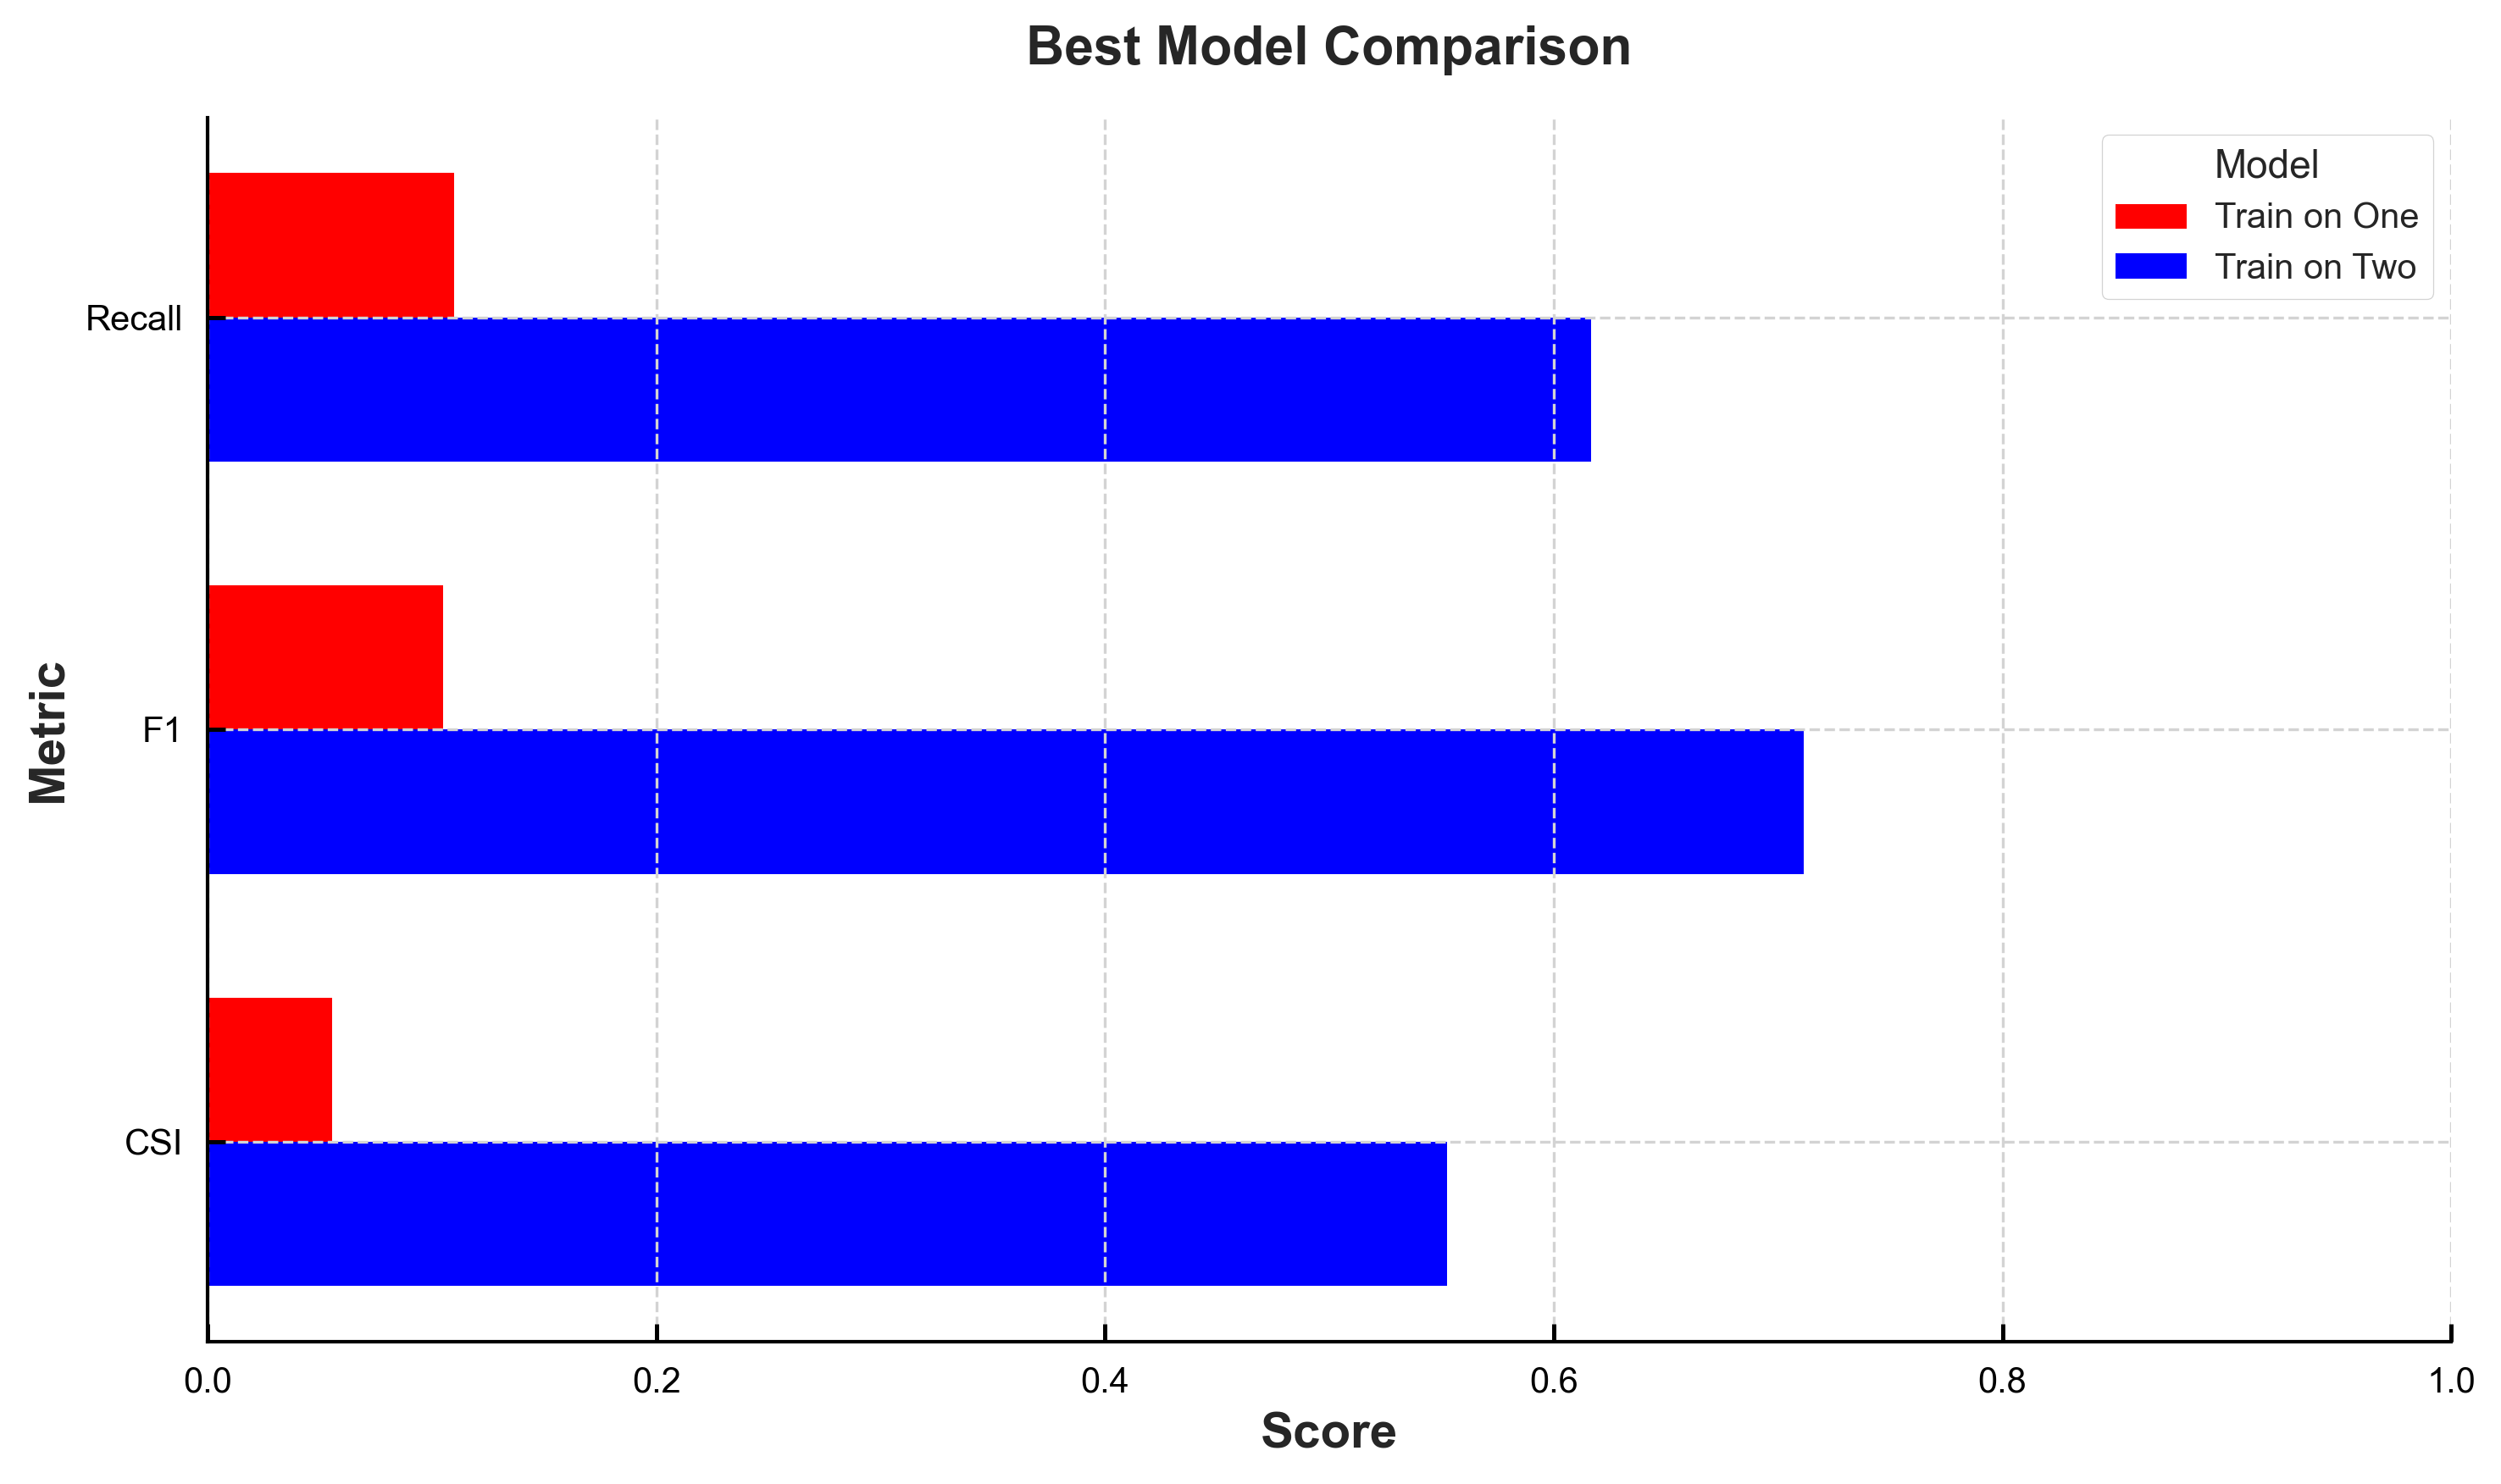

In [14]:
from visualization import visulization_plot, metric_plot
metric_plot(results_01=pd.read_csv('train_on_one.csv'), results_02=pd.read_csv('train_on_two.csv'))

## 4. Feature Importance and Interpretation
Below we use two functions to get the feature importance and SHAP plots for the Harvey event. We re-train the model on Harvey first, and then generate the plots.

We go back to Harvey here because we want to understand the feature relationships in a controlled single-event setting

In [15]:
# Load raw data
df = pd.read_parquet('./results/flood_ml_input_raw.parquet')
print(f"✅ Raw DataFrame shape: {df.shape}")

# Track pixel location and remove no-data values (-9999)
df['pixel_index'] = np.arange(df.shape[0])
df_clean = df[(df != -9999).all(axis=1)].copy()
pixel_indices = df_clean['pixel_index'].values

print(f"✅ Cleaned DataFrame shape: {df_clean.shape}")
df_clean

✅ Raw DataFrame shape: (4003680, 10)
✅ Cleaned DataFrame shape: (2447555, 11)


,VV,VH,DEM,LandUse,Validation,Wetness Index,Flood,Upstream Area,Water Occurrence,Precipitation,pixel_index
11400,-12.394446,-17.349236,92.141449,1,0,548.159180,0.000953,0.007407,0,754.862976,11400
11401,-10.660547,-16.059135,92.786797,1,0,587.827698,0.001541,0.007407,0,754.862976,11401
11402,-10.399331,-15.244548,92.103073,1,0,617.405457,0.002797,0.007407,0,754.862976,11402
11403,-10.867739,-15.852205,91.093643,1,0,593.621216,0.004063,0.007407,0,754.862976,11403
11404,-11.533964,-16.813368,90.908318,1,0,643.305664,0.003403,0.011313,0,754.862976,11404
...,...,...,...,...,...,...,...,...,...,...,...
4001406,-11.289577,-15.340100,3.091765,1,0,791.483276,0.029710,0.069560,0,412.444977,4001406
4001407,-10.751670,-15.165913,3.365446,1,0,696.760254,0.026080,0.058668,0,412.444977,4001407
4001408,-10.839895,-15.200581,3.816211,1,0,718.284302,0.021717,0.045826,0,412.444977,4001408
4001409,-10.344890,-15.415196,4.325716,1,0,746.133667,0.018104,0.027319,0,412.444977,4001409


In [16]:
# Setup the experiment
setup(
    data=df_clean.drop(columns=['pixel_index']),
    target='Validation',
    train_size=0.1,  # default
    session_id=42,
    normalize=True,
    # use_gpu = True,
    ignore_features=['x', 'y']
)


,Description,Value
0,Session id,42
1,Target,Validation
2,Target type,Binary
3,Original data shape,"(2447555, 10)"
4,Transformed data shape,"(2447555, 10)"
5,Transformed train set shape,"(244755, 10)"
6,Transformed test set shape,"(2202800, 10)"
7,Ignore features,2
8,Numeric features,9
9,Rows with missing values,0.0%


Re-register CSI after setup() — PyCaret resets custom metrics on each new experiment

In [17]:
add_metric(
    id='csi',
    name='CSI',
    score_func=csi_score,
    greater_is_better=True,
    target='pred'
)

Name                                                               CSI
Display Name                                                       CSI
Score Function       <pycaret.internal.metrics.EncodedDecodedLabels...
Scorer               make_scorer(csi_score, response_method='predict')
Target                                                            pred
Args                                                                {}
Greater is Better                                                 True
Multiclass                                                        True
Custom                                                            True
Name: csi, dtype: object

In [19]:
best_03 = compare_models(sort='CSI', n_select = 3, exclude=['rbfsvm', 'gpc'], turbo=False) 

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,CSI,TT (Sec)
catboost,CatBoost Classifier,0.8573,0.8972,0.6209,0.8436,0.7153,0.6230,0.6360,0.5568,5.1580
xgboost,Extreme Gradient Boosting,0.8554,0.8944,0.6194,0.8376,0.7121,0.6185,0.6310,0.5530,0.1500
et,Extra Trees Classifier,0.8559,0.8950,0.6078,0.8505,0.7089,0.6166,0.6320,0.5491,2.3600
rf,Random Forest Classifier,0.8520,0.8871,0.5990,0.8432,0.7004,0.6059,0.6215,0.5389,6.9550
lightgbm,Light Gradient Boosting Machine,0.8461,0.8783,0.5834,0.8338,0.6865,0.5887,0.6052,0.5226,0.6650
mlp,MLP Classifier,0.8420,0.8721,0.5894,0.8125,0.6827,0.5811,0.5947,0.5184,4.6340
knn,K Neighbors Classifier,0.8330,0.8416,0.6120,0.7627,0.6790,0.5680,0.5743,0.5141,2.4330
gbc,Gradient Boosting Classifier,0.8340,0.8577,0.5355,0.8292,0.6507,0.5484,0.5710,0.4823,5.2660
ada,Ada Boost Classifier,0.8271,0.8427,0.5207,0.8134,0.6349,0.5286,0.5512,0.4651,1.2470
dt,Decision Tree Classifier,0.7825,0.7383,0.6336,0.6210,0.6272,0.4737,0.4738,0.4569,0.4070


### 4.1. Feature importance plot

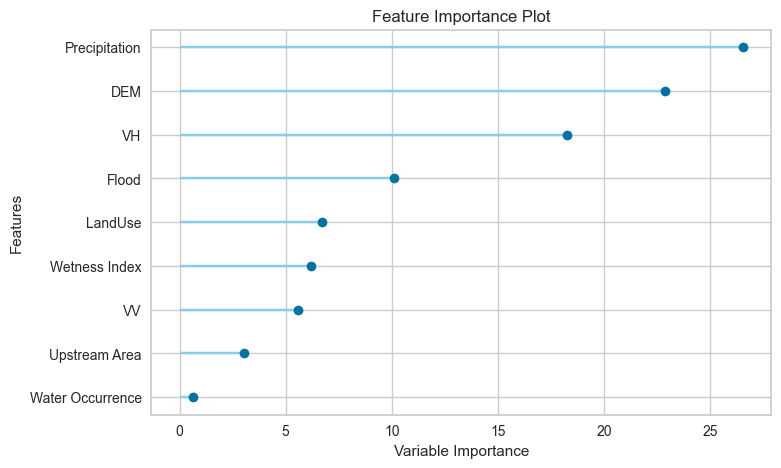

In [20]:
plot_model(best_03[0], plot = 'feature', save=False)

### 4.2. SHAP plot

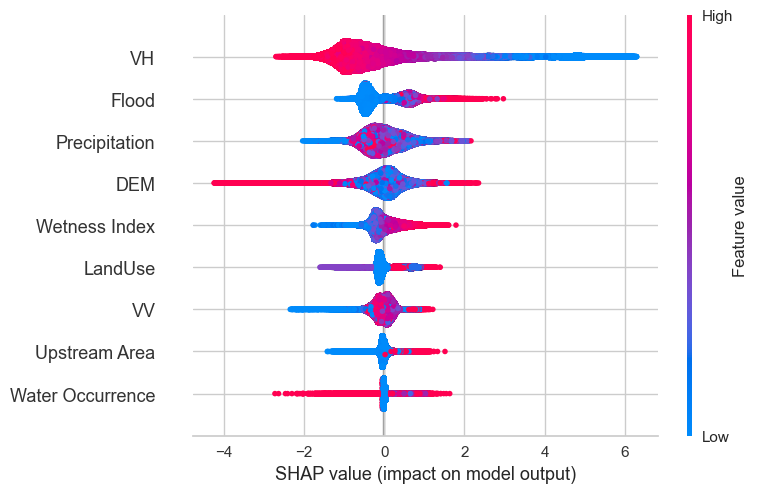

In [21]:

interpret_model(best_03[0], plot='summary')  # shows the plot


### 4.3. Visualization

✅ Saved: Harvey_flood_prediction.tif


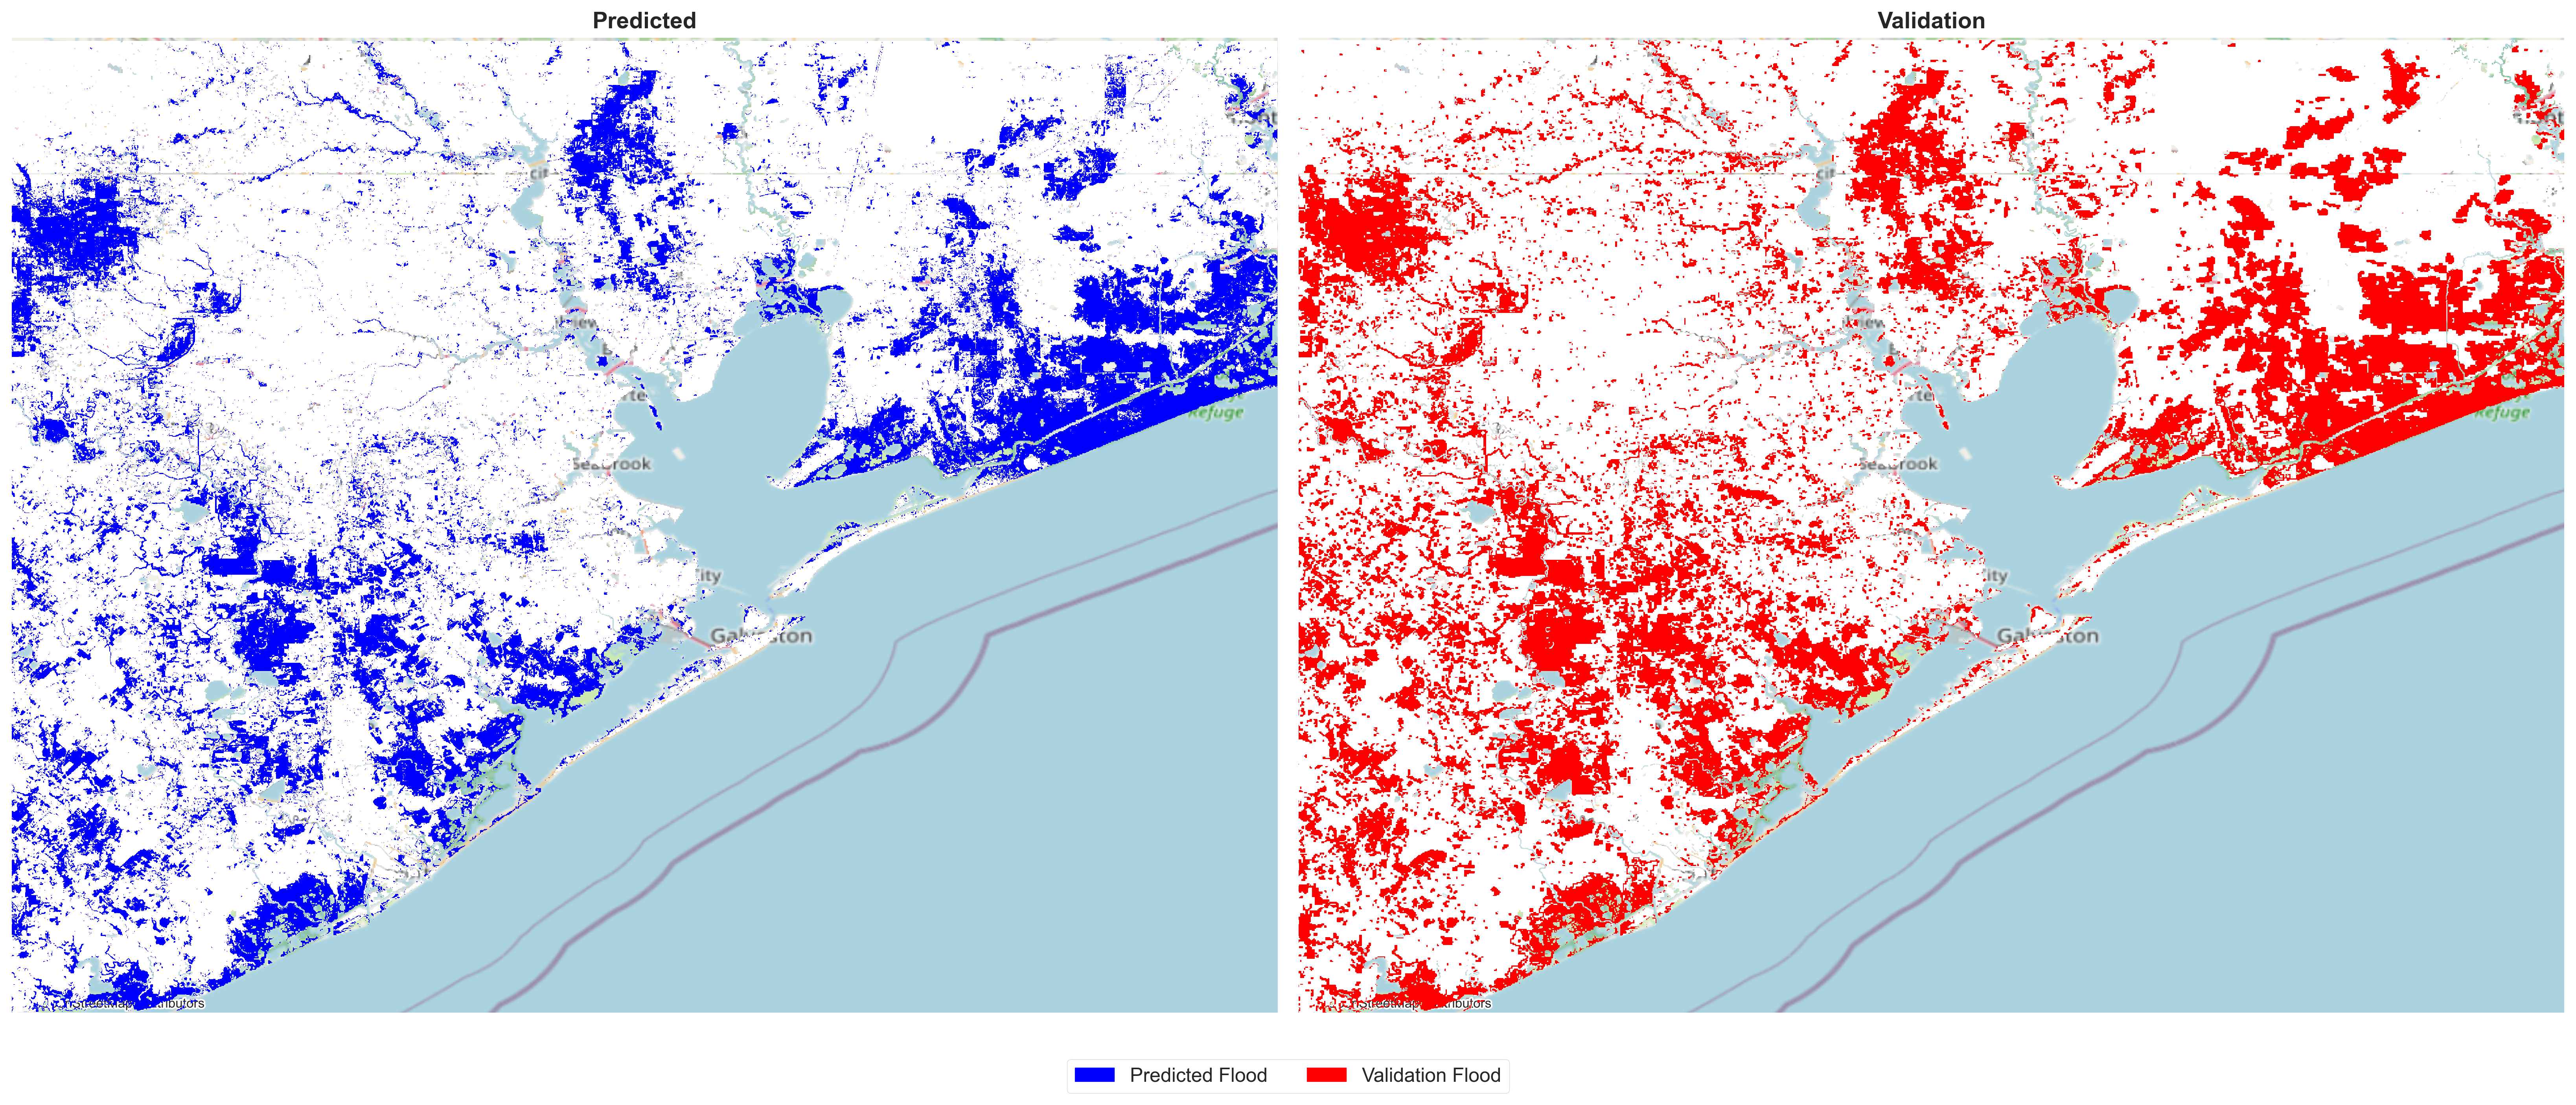

In [22]:
visulization_plot(name='Harvey', model=best_03[0], cleaned_data=df_clean, all_data=df)